In [1]:
# ==========================================================
# COSC2669 / COSC2816
# Individual Task 1 - Fraud Detection Experiment
# Student number: s4160984
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ==========================================================
# 1. LOAD DATASETS
# ==========================================================

credit_df = pd.read_csv("creditcard.csv")
vehicle_df = pd.read_csv("fraud_oracle.csv")

print("Credit Card Dataset Shape:", credit_df.shape)
print("Vehicle Fraud Dataset Shape:", vehicle_df.shape)


Credit Card Dataset Shape: (284807, 31)
Vehicle Fraud Dataset Shape: (15420, 33)


In [3]:
# ==========================================================
# 2. INITIAL DATA EXPLORATION
# ==========================================================

print("\n==============================")
print("CREDIT CARD DATASET")
print("==============================")

print(credit_df.head())

print("\nData types:")
print(credit_df.dtypes)

print("\nMissing values:")
print(credit_df.isnull().sum())

print("\nTotal missing values:")
print(credit_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(credit_df.duplicated().sum())

print("\nClass distribution:")
print(credit_df["Class"].value_counts())

print("\nClass percentage:")
print(
    credit_df["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\n==============================")
print("VEHICLE FRAUD DATASET")
print("==============================")

print(vehicle_df.head())

print("\nData types:")
print(vehicle_df.dtypes)

print("\nMissing values:")
print(vehicle_df.isnull().sum())

print("\nTotal missing values:")
print(vehicle_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(vehicle_df.duplicated().sum())

print("\nClass distribution:")
print(vehicle_df["FraudFound_P"].value_counts())

print("\nClass percentage:")
print(
    vehicle_df["FraudFound_P"]
    .value_counts(normalize=True)
    .mul(100)
)



CREDIT CARD DATASET
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26

In [4]:
# ==========================================================
# 3. REMOVE DUPLICATES FROM CREDIT CARD DATASET
# ==========================================================

credit_clean = credit_df.drop_duplicates().copy()

print("\nOriginal Credit Card Rows:", len(credit_df))

print(
    "Duplicate Rows Removed:",
    len(credit_df) - len(credit_clean)
)

print(
    "Rows After Duplicate Removal:",
    len(credit_clean)
)

print("\nClass Distribution After Removing Duplicates:")
print(credit_clean["Class"].value_counts())

print("\nClass Percentage After Removing Duplicates:")
print(
    credit_clean["Class"]
    .value_counts(normalize=True)
    .mul(100)
)


Original Credit Card Rows: 284807
Duplicate Rows Removed: 1081
Rows After Duplicate Removal: 283726

Class Distribution After Removing Duplicates:
0    283253
1       473
Name: Class, dtype: int64

Class Percentage After Removing Duplicates:
0    99.83329
1     0.16671
Name: Class, dtype: float64


In [5]:
# ==========================================================
# 4. PREPARE CREDIT CARD DATA
# ==========================================================

X_credit = credit_clean.drop(columns=["Class"])
y_credit = credit_clean["Class"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_credit,
    y_credit,
    test_size=0.20,
    random_state=42,
    stratify=y_credit
)

print("\nCredit Card Training Shape:", Xc_train.shape)
print("Credit Card Testing Shape:", Xc_test.shape)

print("\nTraining Class Distribution:")
print(yc_train.value_counts())

print("\nTesting Class Distribution:")
print(yc_test.value_counts())


Credit Card Training Shape: (226980, 30)
Credit Card Testing Shape: (56746, 30)

Training Class Distribution:
0    226602
1       378
Name: Class, dtype: int64

Testing Class Distribution:
0    56651
1       95
Name: Class, dtype: int64


In [6]:
# ==========================================================
# 5. PREPARE VEHICLE FRAUD DATA
# ==========================================================

vehicle_clean = vehicle_df.copy()

X_vehicle = vehicle_clean.drop(
    columns=["FraudFound_P"]
)

y_vehicle = vehicle_clean["FraudFound_P"]

vehicle_numeric_columns = (
    X_vehicle
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

vehicle_categorical_columns = (
    X_vehicle
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

print("\nVehicle Numeric Columns:")
print(vehicle_numeric_columns)

print("\nVehicle Categorical Columns:")
print(vehicle_categorical_columns)

Xv_train, Xv_test, yv_train, yv_test = train_test_split(
    X_vehicle,
    y_vehicle,
    test_size=0.20,
    random_state=42,
    stratify=y_vehicle
)

print("\nVehicle Training Shape:", Xv_train.shape)
print("Vehicle Testing Shape:", Xv_test.shape)


Vehicle Numeric Columns:
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']

Vehicle Categorical Columns:
['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']

Vehicle Training Shape: (12336, 32)
Vehicle Testing Shape: (3084, 32)


In [7]:
# ==========================================================
# 6. VEHICLE DATA PREPROCESSING
# ==========================================================

vehicle_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            vehicle_numeric_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            vehicle_categorical_columns
        )
    ]
) 

In [8]:
# ==========================================================
# 7. MODEL EVALUATION FUNCTION
# ==========================================================

def evaluate_model(
    model_name,
    model,
    X_test,
    y_test
):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    print("\n==================================")
    print(model_name)
    print("==================================")

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            predictions
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    auc = np.nan

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

        auc = roc_auc_score(
            y_test,
            probabilities
        )

        print(
            "ROC-AUC  :",
            round(auc, 4)
        )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    }

In [9]:
# ==========================================================
# 8. DECISION TREE - CREDIT CARD DATA
# ==========================================================

credit_tree = DecisionTreeClassifier(
    random_state=42
)

credit_tree.fit(
    Xc_train,
    yc_train
)

credit_tree_results = evaluate_model(
    "Credit Card - Decision Tree",
    credit_tree,
    Xc_test,
    yc_test
)


Credit Card - Decision Tree

Confusion Matrix:
[[56625    26]
 [   28    67]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746

Accuracy : 0.999
Precision: 0.7204
Recall   : 0.7053
F1 Score : 0.7128
ROC-AUC  : 0.8524


In [10]:
# ==========================================================
# 9. SCALE CREDIT CARD DATA FOR NEURAL NETWORK
# ==========================================================

credit_scaler = StandardScaler()

Xc_train_scaled = credit_scaler.fit_transform(
    Xc_train
)

Xc_test_scaled = credit_scaler.transform(
    Xc_test
)

In [11]:
# ==========================================================
# 10. NEURAL NETWORK - CREDIT CARD DATA
# ==========================================================

credit_mlp = MLPClassifier(
    random_state=42,
    max_iter=300
)

credit_mlp.fit(
    Xc_train_scaled,
    yc_train
)

credit_mlp_results = evaluate_model(
    "Credit Card - Neural Network",
    credit_mlp,
    Xc_test_scaled,
    yc_test
)


Credit Card - Neural Network

Confusion Matrix:
[[56647     4]
 [   27    68]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.72      0.81        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Accuracy : 0.9995
Precision: 0.9444
Recall   : 0.7158
F1 Score : 0.8144
ROC-AUC  : 0.9479


In [12]:
# ==========================================================
# 11. DECISION TREE - VEHICLE FRAUD DATA
# ==========================================================

vehicle_tree = Pipeline(
    steps=[
        (
            "preprocessor",
            vehicle_preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

vehicle_tree.fit(
    Xv_train,
    yv_train
)

vehicle_tree_results = evaluate_model(
    "Vehicle Fraud - Decision Tree",
    vehicle_tree,
    Xv_test,
    yv_test
)


Vehicle Fraud - Decision Tree

Confusion Matrix:
[[2758  141]
 [ 131   54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2899
           1       0.28      0.29      0.28       185

    accuracy                           0.91      3084
   macro avg       0.62      0.62      0.62      3084
weighted avg       0.91      0.91      0.91      3084

Accuracy : 0.9118
Precision: 0.2769
Recall   : 0.2919
F1 Score : 0.2842
ROC-AUC  : 0.6216


In [13]:
# ==========================================================
# 12. NEURAL NETWORK - VEHICLE FRAUD DATA
# ==========================================================

vehicle_mlp = Pipeline(
    steps=[
        (
            "preprocessor",
            vehicle_preprocessor
        ),
        (
            "classifier",
            MLPClassifier(
                random_state=42,
                max_iter=300
            )
        )
    ]
)

vehicle_mlp.fit(
    Xv_train,
    yv_train
)

vehicle_mlp_results = evaluate_model(
    "Vehicle Fraud - Neural Network",
    vehicle_mlp,
    Xv_test,
    yv_test
)



Vehicle Fraud - Neural Network

Confusion Matrix:
[[2807   92]
 [ 152   33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2899
           1       0.26      0.18      0.21       185

    accuracy                           0.92      3084
   macro avg       0.61      0.57      0.59      3084
weighted avg       0.91      0.92      0.91      3084

Accuracy : 0.9209
Precision: 0.264
Recall   : 0.1784
F1 Score : 0.2129
ROC-AUC  : 0.7948


In [14]:
# ==========================================================
# 13. FINAL MODEL COMPARISON
# ==========================================================

results = pd.DataFrame([
    credit_tree_results,
    credit_mlp_results,
    vehicle_tree_results,
    vehicle_mlp_results
])

print("\n==================================")
print("FINAL MODEL COMPARISON")
print("==================================")

print(
    results.round(4)
)

results.to_csv(
    "model_results.csv",
    index=False
)


FINAL MODEL COMPARISON
                            Model  Accuracy  Precision  Recall      F1  \
0     Credit Card - Decision Tree    0.9990     0.7204  0.7053  0.7128   
1    Credit Card - Neural Network    0.9995     0.9444  0.7158  0.8144   
2   Vehicle Fraud - Decision Tree    0.9118     0.2769  0.2919  0.2842   
3  Vehicle Fraud - Neural Network    0.9209     0.2640  0.1784  0.2129   

   ROC_AUC  
0   0.8524  
1   0.9479  
2   0.6216  
3   0.7948  


In [15]:
# ==========================================================
# TASK 2 - 5-FOLD STRATIFIED CROSS-VALIDATION
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


# ----------------------------------------------------------
# 1. CROSS-VALIDATION SETUP
# ----------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ----------------------------------------------------------
# 2. HELPER FUNCTION
# ----------------------------------------------------------

def run_cross_validation(model_name, model, X, y):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    result = {
        "Model": model_name
    }

    print("\n==============================================")
    print(model_name)
    print("==============================================")

    for metric in scoring:

        values = scores["test_" + metric]

        mean_value = values.mean()
        std_value = values.std()

        result[metric + "_mean"] = mean_value
        result[metric + "_std"] = std_value

        print(
            metric.upper(),
            ": Mean =",
            round(mean_value, 4),
            "| Std =",
            round(std_value, 4)
        )

    return result


# ----------------------------------------------------------
# 3. CREDIT CARD - DECISION TREE
# ----------------------------------------------------------

credit_tree_cv_model = DecisionTreeClassifier(
    random_state=42
)

credit_tree_cv_result = run_cross_validation(
    "Credit Card - Decision Tree",
    credit_tree_cv_model,
    Xc_train,
    yc_train
)


# ----------------------------------------------------------
# 4. CREDIT CARD - NEURAL NETWORK
#
# Scaling is inside the Pipeline so StandardScaler is fitted
# separately within each CV training fold.
# ----------------------------------------------------------

credit_mlp_cv_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            MLPClassifier(
                random_state=42,
                max_iter=300
            )
        )
    ]
)

credit_mlp_cv_result = run_cross_validation(
    "Credit Card - Neural Network",
    credit_mlp_cv_model,
    Xc_train,
    yc_train
)


# ----------------------------------------------------------
# 5. VEHICLE FRAUD - DECISION TREE
#
# vehicle_preprocessor was already defined in Task 1.
# Keeping it inside the Pipeline prevents preprocessing
# information from leaking between CV folds.
# ----------------------------------------------------------

vehicle_tree_cv_model = Pipeline(
    steps=[
        (
            "preprocessor",
            vehicle_preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

vehicle_tree_cv_result = run_cross_validation(
    "Vehicle Fraud - Decision Tree",
    vehicle_tree_cv_model,
    Xv_train,
    yv_train
)


# ----------------------------------------------------------
# 6. VEHICLE FRAUD - NEURAL NETWORK
# ----------------------------------------------------------

vehicle_mlp_cv_model = Pipeline(
    steps=[
        (
            "preprocessor",
            vehicle_preprocessor
        ),
        (
            "classifier",
            MLPClassifier(
                random_state=42,
                max_iter=300
            )
        )
    ]
)

vehicle_mlp_cv_result = run_cross_validation(
    "Vehicle Fraud - Neural Network",
    vehicle_mlp_cv_model,
    Xv_train,
    yv_train
)


# ----------------------------------------------------------
# 7. CREATE SUMMARY TABLE
# ----------------------------------------------------------

cv_results = pd.DataFrame([
    credit_tree_cv_result,
    credit_mlp_cv_result,
    vehicle_tree_cv_result,
    vehicle_mlp_cv_result
])


# Make column names easier to read
cv_results = cv_results.rename(
    columns={
        "precision_mean": "Precision Mean",
        "precision_std": "Precision Std",
        "recall_mean": "Recall Mean",
        "recall_std": "Recall Std",
        "f1_mean": "F1 Mean",
        "f1_std": "F1 Std",
        "roc_auc_mean": "ROC-AUC Mean",
        "roc_auc_std": "ROC-AUC Std"
    }
)


print("\n\n==============================================")
print("5-FOLD STRATIFIED CROSS-VALIDATION SUMMARY")
print("==============================================")

print(
    cv_results.round(4).to_string(index=False)
)


# ----------------------------------------------------------
# 8. ORIGINAL TASK 1 HOLDOUT RESULTS
# ----------------------------------------------------------

original_results = pd.DataFrame({
    "Model": [
        "Credit Card - Decision Tree",
        "Credit Card - Neural Network",
        "Vehicle Fraud - Decision Tree",
        "Vehicle Fraud - Neural Network"
    ],

    "Original Precision": [
        0.7204,
        0.9444,
        0.2769,
        0.2640
    ],

    "Original Recall": [
        0.7053,
        0.7158,
        0.2919,
        0.1784
    ],

    "Original F1": [
        0.7128,
        0.8144,
        0.2842,
        0.2129
    ],

    "Original ROC-AUC": [
        0.8524,
        0.9479,
        0.6216,
        0.7948
    ]
})


# ----------------------------------------------------------
# 9. COMPARE ORIGINAL HOLDOUT WITH CV RESULTS
# ----------------------------------------------------------

comparison = original_results.merge(
    cv_results,
    on="Model"
)


print("\n\n==============================================")
print("TASK 1 HOLDOUT VS TASK 2 CROSS-VALIDATION")
print("==============================================")

comparison_columns = [
    "Model",

    "Original Precision",
    "Precision Mean",
    "Precision Std",

    "Original Recall",
    "Recall Mean",
    "Recall Std",

    "Original F1",
    "F1 Mean",
    "F1 Std",

    "Original ROC-AUC",
    "ROC-AUC Mean",
    "ROC-AUC Std"
]

print(
    comparison[comparison_columns]
    .round(4)
    .to_string(index=False)
)


# ----------------------------------------------------------
# 10. SAVE RESULTS
# ----------------------------------------------------------

cv_results.to_csv(
    "task2_cross_validation_results.csv",
    index=False
)

comparison[comparison_columns].to_csv(
    "task2_holdout_vs_cv.csv",
    index=False
)

print("\nResults saved:")
print("- task2_cross_validation_results.csv")
print("- task2_holdout_vs_cv.csv")


Credit Card - Decision Tree
PRECISION : Mean = 0.7583 | Std = 0.0269
RECALL : Mean = 0.7431 | Std = 0.0512
F1 : Mean = 0.7495 | Std = 0.0292
ROC_AUC : Mean = 0.8714 | Std = 0.0256

Credit Card - Neural Network
PRECISION : Mean = 0.9128 | Std = 0.0433
RECALL : Mean = 0.775 | Std = 0.0779
F1 : Mean = 0.8341 | Std = 0.0349
ROC_AUC : Mean = 0.965 | Std = 0.0194

Vehicle Fraud - Decision Tree
PRECISION : Mean = 0.3112 | Std = 0.0768
RECALL : Mean = 0.3389 | Std = 0.0599
F1 : Mean = 0.3235 | Std = 0.0677
ROC_AUC : Mean = 0.6449 | Std = 0.0333

Vehicle Fraud - Neural Network
PRECISION : Mean = 0.211 | Std = 0.0164
RECALL : Mean = 0.122 | Std = 0.0232
F1 : Mean = 0.1538 | Std = 0.0215
ROC_AUC : Mean = 0.768 | Std = 0.0084


5-FOLD STRATIFIED CROSS-VALIDATION SUMMARY
                          Model  Precision Mean  Precision Std  Recall Mean  Recall Std  F1 Mean  F1 Std  ROC-AUC Mean  ROC-AUC Std
    Credit Card - Decision Tree          0.7583         0.0269       0.7431      0.0512   0.7495  


Credit Card - Decision Tree
                       Model  Training Samples  Training F1 Mean  Training F1 Std  Validation F1 Mean  Validation F1 Std
 Credit Card - Decision Tree             18158               1.0              0.0              0.6593             0.0955
 Credit Card - Decision Tree             45396               1.0              0.0              0.7115             0.0480
 Credit Card - Decision Tree             90792               1.0              0.0              0.7319             0.0206
 Credit Card - Decision Tree            136188               1.0              0.0              0.7571             0.0218
 Credit Card - Decision Tree            181584               1.0              0.0              0.7495             0.0292


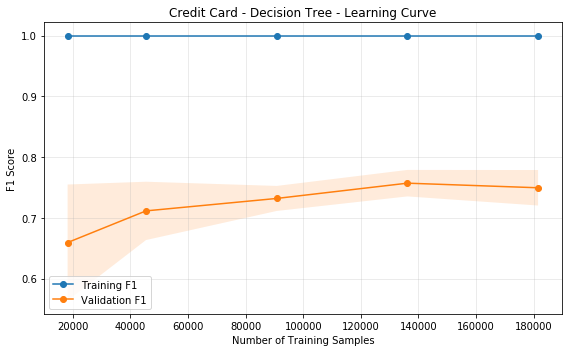


Credit Card - Neural Network
                        Model  Training Samples  Training F1 Mean  Training F1 Std  Validation F1 Mean  Validation F1 Std
 Credit Card - Neural Network             18158            0.9556           0.0439              0.7698             0.0525
 Credit Card - Neural Network             45396            0.9722           0.0156              0.8067             0.0255
 Credit Card - Neural Network             90792            0.9608           0.0085              0.8237             0.0265
 Credit Card - Neural Network            136188            0.9513           0.0138              0.8188             0.0325
 Credit Card - Neural Network            181584            0.9353           0.0291              0.8247             0.0143


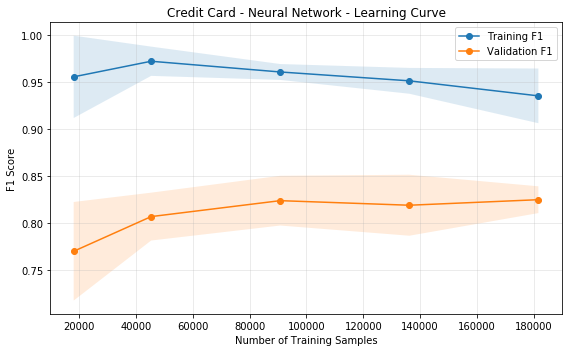


Vehicle Fraud - Decision Tree
                         Model  Training Samples  Training F1 Mean  Training F1 Std  Validation F1 Mean  Validation F1 Std
 Vehicle Fraud - Decision Tree               986               1.0              0.0              0.1890             0.0430
 Vehicle Fraud - Decision Tree              2467               1.0              0.0              0.2101             0.0485
 Vehicle Fraud - Decision Tree              4934               1.0              0.0              0.2418             0.0398
 Vehicle Fraud - Decision Tree              7401               1.0              0.0              0.2855             0.0249
 Vehicle Fraud - Decision Tree              9868               1.0              0.0              0.3180             0.0705


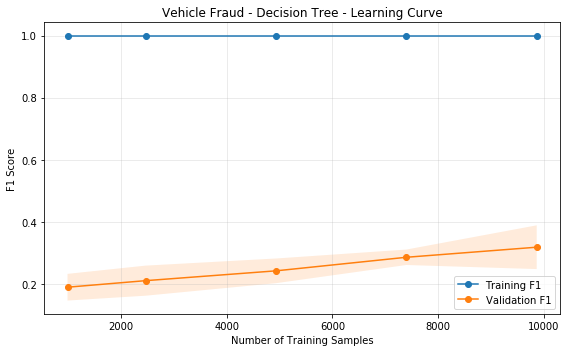


Vehicle Fraud - Neural Network
                          Model  Training Samples  Training F1 Mean  Training F1 Std  Validation F1 Mean  Validation F1 Std
 Vehicle Fraud - Neural Network               986               1.0              0.0              0.1055             0.0289
 Vehicle Fraud - Neural Network              2467               1.0              0.0              0.1044             0.0410
 Vehicle Fraud - Neural Network              4934               1.0              0.0              0.1616             0.0348
 Vehicle Fraud - Neural Network              7401               1.0              0.0              0.1565             0.0176
 Vehicle Fraud - Neural Network              9868               1.0              0.0              0.1671             0.0226


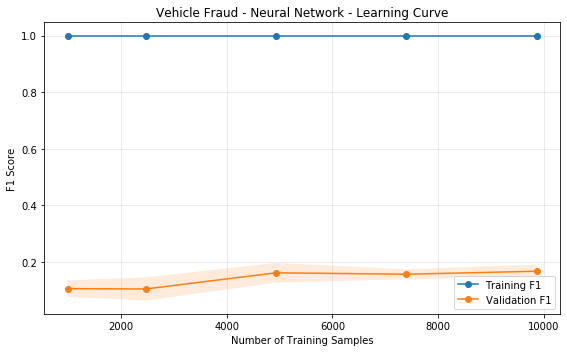



TRAINING SET SIZE - COMPLETE RESULTS
                          Model  Training Samples  Training F1 Mean  Training F1 Std  Validation F1 Mean  Validation F1 Std
    Credit Card - Decision Tree             18158            1.0000           0.0000              0.6593             0.0955
    Credit Card - Decision Tree             45396            1.0000           0.0000              0.7115             0.0480
    Credit Card - Decision Tree             90792            1.0000           0.0000              0.7319             0.0206
    Credit Card - Decision Tree            136188            1.0000           0.0000              0.7571             0.0218
    Credit Card - Decision Tree            181584            1.0000           0.0000              0.7495             0.0292
   Credit Card - Neural Network             18158            0.9556           0.0439              0.7698             0.0525
   Credit Card - Neural Network             45396            0.9722           0.0156         

In [16]:
# ==========================================================
# TASK 2 - LEARNING CURVE / TRAINING SET SIZE ANALYSIS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve


# ----------------------------------------------------------
# TRAINING SET SIZES
# ----------------------------------------------------------

train_sizes = np.array([
    0.10,
    0.25,
    0.50,
    0.75,
    1.00
])


# ----------------------------------------------------------
# HELPER FUNCTION
# ----------------------------------------------------------

def analyse_learning_curve(
    model_name,
    model,
    X,
    y
):

    sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring="f1",
        shuffle=True,
        random_state=42,
        n_jobs=-1
    )

    train_mean = np.mean(
        train_scores,
        axis=1
    )

    train_std = np.std(
        train_scores,
        axis=1
    )

    validation_mean = np.mean(
        validation_scores,
        axis=1
    )

    validation_std = np.std(
        validation_scores,
        axis=1
    )

    result = pd.DataFrame({
        "Model": model_name,
        "Training Samples": sizes,
        "Training F1 Mean": train_mean,
        "Training F1 Std": train_std,
        "Validation F1 Mean": validation_mean,
        "Validation F1 Std": validation_std
    })


    print("\n==============================================")
    print(model_name)
    print("==============================================")

    print(
        result.round(4).to_string(index=False)
    )


    # ------------------------------------------------------
    # LEARNING CURVE GRAPH
    # ------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        sizes,
        train_mean,
        marker="o",
        label="Training F1"
    )

    plt.plot(
        sizes,
        validation_mean,
        marker="o",
        label="Validation F1"
    )

    plt.fill_between(
        sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15
    )

    plt.fill_between(
        sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15
    )

    plt.xlabel("Number of Training Samples")
    plt.ylabel("F1 Score")

    plt.title(
        model_name + " - Learning Curve"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    return result


# ==========================================================
# 1. CREDIT CARD - DECISION TREE
# ==========================================================

lc_credit_tree = analyse_learning_curve(
    "Credit Card - Decision Tree",
    credit_tree_cv_model,
    Xc_train,
    yc_train
)


# ==========================================================
# 2. CREDIT CARD - NEURAL NETWORK
# ==========================================================

lc_credit_mlp = analyse_learning_curve(
    "Credit Card - Neural Network",
    credit_mlp_cv_model,
    Xc_train,
    yc_train
)


# ==========================================================
# 3. VEHICLE FRAUD - DECISION TREE
# ==========================================================

lc_vehicle_tree = analyse_learning_curve(
    "Vehicle Fraud - Decision Tree",
    vehicle_tree_cv_model,
    Xv_train,
    yv_train
)


# ==========================================================
# 4. VEHICLE FRAUD - NEURAL NETWORK
# ==========================================================

lc_vehicle_mlp = analyse_learning_curve(
    "Vehicle Fraud - Neural Network",
    vehicle_mlp_cv_model,
    Xv_train,
    yv_train
)


# ==========================================================
# COMBINE ALL RESULTS
# ==========================================================

learning_curve_results = pd.concat(
    [
        lc_credit_tree,
        lc_credit_mlp,
        lc_vehicle_tree,
        lc_vehicle_mlp
    ],
    ignore_index=True
)


print("\n\n==============================================")
print("TRAINING SET SIZE - COMPLETE RESULTS")
print("==============================================")

print(
    learning_curve_results
    .round(4)
    .to_string(index=False)
)


# ----------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------

learning_curve_results.to_csv(
    "task2_learning_curve_results.csv",
    index=False
)

print("\nResults saved:")
print("- task2_learning_curve_results.csv")

In [17]:
!pip install fairlearn

In [18]:
# ==========================================================
# TASK 2 - FAIRNESS / BIAS ANALYSIS USING FAIRLEARN
# Sensitive attribute: Sex
# ==========================================================

import pandas as pd
import numpy as np

from fairlearn.metrics import MetricFrame
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ----------------------------------------------------------
# 1. DEFINE FAIRNESS METRICS
# ----------------------------------------------------------

def selection_rate(y_true, y_pred):
    return np.mean(y_pred)


def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    if (fp + tn) == 0:
        return np.nan

    return fp / (fp + tn)


fairness_metrics = {
    "Selection Rate": selection_rate,

    "Precision": lambda y_true, y_pred:
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "Recall / TPR": lambda y_true, y_pred:
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "F1": lambda y_true, y_pred:
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "False Positive Rate": false_positive_rate
}


# ----------------------------------------------------------
# 2. SENSITIVE ATTRIBUTE
# ----------------------------------------------------------

sensitive_sex = Xv_test["Sex"]

print("==============================================")
print("TEST SET GROUP DISTRIBUTION")
print("==============================================")

print(
    sensitive_sex
    .value_counts()
)


# ----------------------------------------------------------
# 3. ACTUAL FRAUD PREVALENCE BY GROUP
# ----------------------------------------------------------

group_information = pd.DataFrame({
    "Sex": sensitive_sex,
    "Actual Fraud": np.asarray(yv_test)
})


prevalence_table = (
    group_information
    .groupby("Sex")
    .agg(
        Group_Size=("Actual Fraud", "size"),
        Actual_Fraud_Count=("Actual Fraud", "sum"),
        Actual_Fraud_Rate=("Actual Fraud", "mean")
    )
)


print("\n==============================================")
print("ACTUAL FRAUD PREVALENCE BY SEX")
print("==============================================")

print(
    prevalence_table.round(4)
)


# ----------------------------------------------------------
# 4. VEHICLE DECISION TREE PREDICTIONS
# ----------------------------------------------------------

vehicle_tree_predictions = vehicle_tree.predict(
    Xv_test
)


vehicle_tree_fairness = MetricFrame(
    metrics=fairness_metrics,
    y_true=yv_test,
    y_pred=vehicle_tree_predictions,
    sensitive_features=sensitive_sex
)


print("\n==============================================")
print("VEHICLE DECISION TREE - OVERALL")
print("==============================================")

print(
    vehicle_tree_fairness.overall
)


print("\n==============================================")
print("VEHICLE DECISION TREE - BY SEX")
print("==============================================")

print(
    vehicle_tree_fairness.by_group.round(4)
)


print("\n==============================================")
print("VEHICLE DECISION TREE - GROUP DIFFERENCE")
print("==============================================")

print(
    vehicle_tree_fairness.difference(
        method="between_groups"
    ).round(4)
)


# ----------------------------------------------------------
# 5. VEHICLE NEURAL NETWORK PREDICTIONS
# ----------------------------------------------------------

vehicle_mlp_predictions = vehicle_mlp.predict(
    Xv_test
)


vehicle_mlp_fairness = MetricFrame(
    metrics=fairness_metrics,
    y_true=yv_test,
    y_pred=vehicle_mlp_predictions,
    sensitive_features=sensitive_sex
)


print("\n==============================================")
print("VEHICLE NEURAL NETWORK - OVERALL")
print("==============================================")

print(
    vehicle_mlp_fairness.overall
)


print("\n==============================================")
print("VEHICLE NEURAL NETWORK - BY SEX")
print("==============================================")

print(
    vehicle_mlp_fairness.by_group.round(4)
)


print("\n==============================================")
print("VEHICLE NEURAL NETWORK - GROUP DIFFERENCE")
print("==============================================")

print(
    vehicle_mlp_fairness.difference(
        method="between_groups"
    ).round(4)
)


# ----------------------------------------------------------
# 6. CREATE COMBINED FAIRNESS TABLE
# ----------------------------------------------------------

tree_table = (
    vehicle_tree_fairness
    .by_group
    .reset_index()
)

tree_table["Model"] = "Decision Tree"


mlp_table = (
    vehicle_mlp_fairness
    .by_group
    .reset_index()
)

mlp_table["Model"] = "Neural Network"


fairness_results = pd.concat(
    [
        tree_table,
        mlp_table
    ],
    ignore_index=True
)


# Put model first
columns = (
    ["Model", "Sex"] +
    [
        column
        for column in fairness_results.columns
        if column not in ["Model", "Sex"]
    ]
)

fairness_results = fairness_results[
    columns
]


print("\n==============================================")
print("COMPLETE FAIRNESS COMPARISON")
print("==============================================")

print(
    fairness_results
    .round(4)
    .to_string(index=False)
)


# ----------------------------------------------------------
# 7. SAVE RESULTS
# ----------------------------------------------------------

fairness_results.to_csv(
    "task2_fairness_by_sex.csv",
    index=False
)

prevalence_table.to_csv(
    "task2_fraud_prevalence_by_sex.csv"
)

print("\nResults saved:")
print("- task2_fairness_by_sex.csv")
print("- task2_fraud_prevalence_by_sex.csv")

TEST SET GROUP DISTRIBUTION
Male      2583
Female     501
Name: Sex, dtype: int64

ACTUAL FRAUD PREVALENCE BY SEX
        Group_Size  Actual_Fraud_Count  Actual_Fraud_Rate
Sex                                                      
Female         501                  21             0.0419
Male          2583                 164             0.0635

VEHICLE DECISION TREE - OVERALL
Selection Rate         0.0632296
Precision               0.276923
Recall / TPR            0.291892
F1                      0.284211
False Positive Rate    0.0486375
dtype: object

VEHICLE DECISION TREE - BY SEX
       Selection Rate Precision Recall / TPR        F1 False Positive Rate
Sex                                                                       
Female      0.0479042  0.208333     0.238095  0.222222           0.0395833
Male        0.0662021   0.28655      0.29878  0.292537           0.0504341

VEHICLE DECISION TREE - GROUP DIFFERENCE
Selection Rate         0.0183
Precision              0.0782
Recall /